# Clone inference from bulk DNA with PyClone-VI

Most tumour sequencing is still **bulk**: one mixture, one set of read counts, no cells. What you can
recover from that is not a tree of cells but a set of **clones** — groups of mutations that rise and
fall together because they sit in the same population — each with a cancer-cell fraction saying how
much of the tumour carries it.

**[PyClone-VI](https://github.com/Roth-Lab/pyclone-vi)** (Gillis & Roth 2020) is the standard tool
for that. It runs **in this notebook's own kernel** (`Python (iscc-pyclonevi)`) through its Python
API, so the fitted results are here rather than in a file somewhere.

| file | what it is | who sees it |
|---|---|---|
| `input.tsv` | per-mutation bulk read counts, copy number and purity | the tool |
| `truth.csv` | each mutation's true cancer-cell fraction and clone | **scoring only** |

Generated by `python validation/make_analysis_data.py --only dna` — the same lesion
[HMMcopy](tool_hmmcopy_R.ipynb) and [SCITE](tool_scite_trees.ipynb) work on, so the clones found here
and the tree found there describe one tumour.

**Two things the input is not given from truth.** Copy number is HMMcopy's call, not `iscc`'s. And
because depth-based calling yields total copy number only, the total is split the conventional way —
one minor copy wherever the total allows — which is an assumption, stated here rather than buried.

In [1]:
import json, os, tempfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pyclone_vi import run

DATA = os.path.join("..", "analysis_data", "dna")
assert os.path.isdir(DATA), (
    f"dataset not found at {DATA}\n"
    "  generate it first:  python validation/make_analysis_data.py --only dna")

IN   = os.path.join(DATA, "pyclonevi", "input.tsv")
inp  = pd.read_csv(IN, sep="\t")
meta = json.load(open(os.path.join(DATA, "meta.json")))

inp["vaf"] = inp["alt_counts"] / (inp["alt_counts"] + inp["ref_counts"])
print(f"{len(inp)} mutations, tumour content {inp['tumour_content'].iloc[0]:.2f}")
print(f"depth: median {int((inp.alt_counts + inp.ref_counts).median())}, "
      f"VAF median {inp['vaf'].median():.3f}")
print("called copy number states present:",
      sorted(set(zip(inp.major_cn, inp.minor_cn))))
inp.head(3)

300 mutations, tumour content 0.50
depth: median 78, VAF median 0.016
called copy number states present: [(1, 0), (1, 1), (2, 1)]


,mutation_id,sample_id,ref_counts,alt_counts,major_cn,minor_cn,normal_cn,tumour_content,vaf
0,G_0_115,bulk,76,2,1,1,2,0.5,0.025641
1,G_0_134,bulk,29,1,1,1,2,0.5,0.033333
2,G_0_141,bulk,40,1,1,1,2,0.5,0.024390


## What a bulk VAF looks like before anyone clusters it

The whole method rests on one observation: mutations in the same clone sit at the same cancer-cell
fraction, so their variant allele fractions pile up at the same place — modulated by copy number and
diluted by however much normal tissue is in the sample.

This lesion is a **low-purity** one, which is the realistic case and the hard one: the mixture is
mostly stroma, so every VAF is pulled down towards zero and the clusters sit close together.

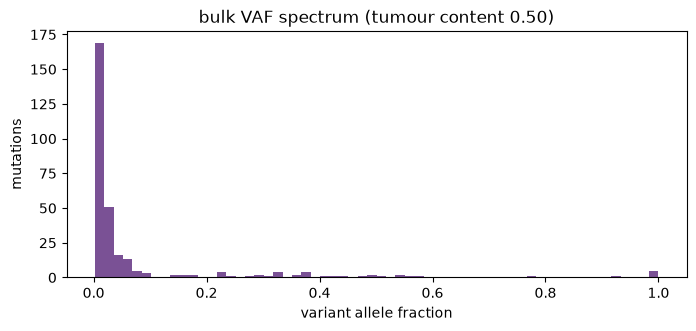

In [2]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(inp["vaf"], bins=60, color="#7a5195")
ax.set_xlabel("variant allele fraction"); ax.set_ylabel("mutations")
ax.set_title(f"bulk VAF spectrum (tumour content {inp['tumour_content'].iloc[0]:.2f})")
plt.show()

## Fitting

PyClone-VI's own entry points. `fit` runs the variational inference over a grid of restarts and
writes an HDF5 of the fitted model; `write_results_file` turns that into the per-mutation table of
cluster assignments and cellular prevalences. `num_clusters` is an upper bound — the mixture prior
prunes the ones it does not need, so it is set above the number of clones anyone expects.

In [3]:
work = tempfile.mkdtemp()
h5   = os.path.join(work, "fit.h5")
out  = os.path.join(work, "results.tsv")

run.fit(IN, h5, num_clusters=10, density="beta-binomial",
        num_restarts=10, num_grid_points=100, seed=1, print_freq=10_000)
run.write_results_file(h5, out)

res = pd.read_csv(out, sep="\t")
print(f"\n{res['cluster_id'].nunique()} clusters kept of the 10 allowed")
print(res.groupby("cluster_id")
         .agg(n_mutations=("mutation_id", "size"),
              cellular_prevalence=("cellular_prevalence", "mean"))
         .sort_values("cellular_prevalence", ascending=False).round(3).to_string())

####################################################################################################


PyClone-VI: Fit


####################################################################################################


Running with the following parameters:



Density: beta-binomial


...

PyClone-VI: Write Results File


####################################################################################################


Results table written to:
/var/folders/d4/tfj5y66n2zzddb2k40xhyhk80000gp/T/tmpf3szq4af/results.tsv



####################################################################################################



2 clusters kept of the 10 allowed
            n_mutations  cellular_prevalence
cluster_id                                  
1                    43                 1.00
0                   257                 0.05


## The clusters PyClone-VI found

Each cluster is a candidate clone: a set of mutations the model thinks occupy the same fraction of
cancer cells. Plotted against the raw VAFs, a good fit puts the cluster prevalences where the peaks
are.

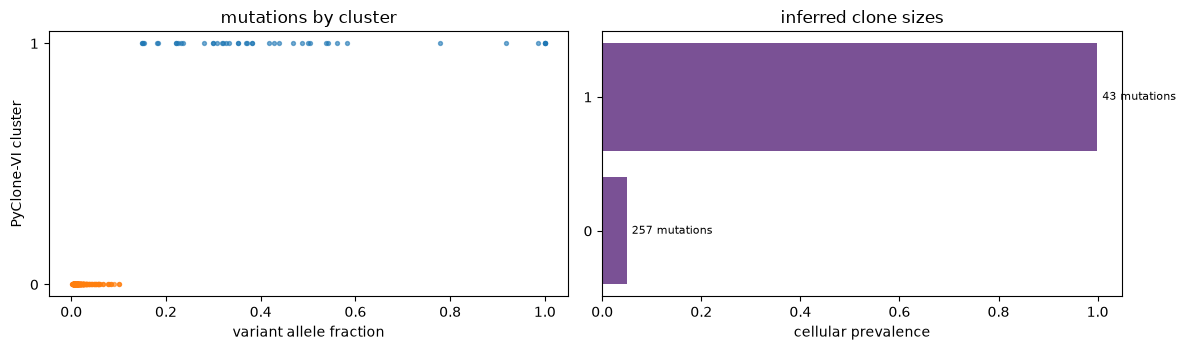

In [4]:
merged = inp.merge(res[["mutation_id", "cluster_id", "cellular_prevalence"]], on="mutation_id")
order  = (merged.groupby("cluster_id")["cellular_prevalence"].mean()
                .sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for k in order:
    sub = merged[merged["cluster_id"] == k]
    axes[0].scatter(sub["vaf"], np.full(len(sub), k), s=8, alpha=0.6)
axes[0].set_xlabel("variant allele fraction"); axes[0].set_ylabel("PyClone-VI cluster")
axes[0].set_yticks(order); axes[0].set_title("mutations by cluster")

prev = merged.groupby("cluster_id")["cellular_prevalence"].mean().loc[order]
size = merged.groupby("cluster_id").size().loc[order]
axes[1].barh([str(k) for k in order], prev.values, color="#7a5195")
for y, (p, n) in enumerate(zip(prev.values, size.values)):
    axes[1].text(p + 0.01, y, f"{n} mutations", va="center", fontsize=8)
axes[1].set_xlabel("cellular prevalence"); axes[1].set_title("inferred clone sizes")
axes[1].invert_yaxis()
fig.tight_layout()

## Scoring against the truth

Two questions. Does the **cellular prevalence** track the fraction of cancer cells that really carry
each mutation? And does the **clustering** group mutations the way the clones actually do?

Prevalence is scored by correlation with the true cancer-cell fraction. The clustering is scored by
adjusted Rand index, which does not care how clusters are numbered — against a mutation's real clonal
identity, meaning **the set of clones that carry it**. That distinction matters: a truncal mutation is
in every clone, and forcing each mutation to belong to one clone would split groups that genuinely
belong together and make the score meaningless.

PyClone-VI vs iscc ground truth, over 300 mutations
  cellular prevalence vs true CCF:  Pearson r 0.96   Spearman 0.55
  clustering vs true clone:         ARI 0.73
  clusters found 2, true clonal groups present 5

true clonal groups (which clones carry the mutation -> how many mutations, mean CCF):
                n_mutations  true_ccf
carrier_clones                       
c0000                   242     0.011
c0001                     2     0.071
c0010                    16     0.084
c1110                     8     0.921
c1111                    32     0.999


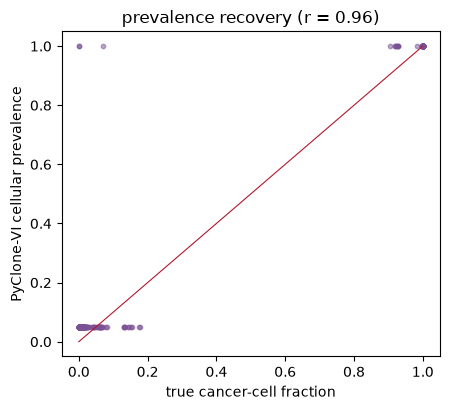

In [5]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import adjusted_rand_score

truth = pd.read_csv(os.path.join(DATA, "pyclonevi", "truth.csv"))
sc = merged.merge(truth, on="mutation_id")

r_p = pearsonr(sc["cellular_prevalence"], sc["true_ccf"])[0]
r_s = spearmanr(sc["cellular_prevalence"], sc["true_ccf"])[0]
ari = adjusted_rand_score(sc["true_cluster"], sc["cluster_id"])
print(f"PyClone-VI vs iscc ground truth, over {len(sc)} mutations")
print(f"  cellular prevalence vs true CCF:  Pearson r {r_p:.2f}   Spearman {r_s:.2f}")
print(f"  clustering vs true clonal group:  ARI {ari:.2f}")
print(f"  clusters found {sc['cluster_id'].nunique()}, true clonal groups present "
      f"{sc['true_cluster'].nunique()}")
print("\ntrue clonal groups (which clones carry the mutation -> how many mutations, mean CCF):")
print(sc.groupby("carrier_clones")
        .agg(n_mutations=("mutation_id", "size"), true_ccf=("true_ccf", "mean"))
        .sort_values("true_ccf").round(3).to_string())

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.scatter(sc["true_ccf"], sc["cellular_prevalence"], s=10, alpha=0.5, c="#7a5195")
lim = [0, max(1.0, sc[["true_ccf", "cellular_prevalence"]].values.max())]
ax.plot(lim, lim, color="#b2182b", lw=0.8)
ax.set_xlabel("true cancer-cell fraction"); ax.set_ylabel("PyClone-VI cellular prevalence")
ax.set_title(f"prevalence recovery (r = {r_p:.2f})")
fig.tight_layout()

## What to take from it

Bulk sequencing is what most tumours actually get, and this is what it can and cannot tell you. The
prevalence ordering comes back — which mutations are clonal and which are in a minority of cells —
while the *number* of clones is bounded by what a single low-purity sample can resolve.

The comparison worth making is with the single-cell view of the **same tumour** in
[Tree reconstruction with SCITE](tool_scite_trees.ipynb). There, individual cells make the nesting
directly observable; here it has to be inferred from where the allele fractions pile up. `iscc` can
put both against the same answer key because it grew the cells that both are summarising.